In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/playground-series-s4e12/sample_submission.csv
/kaggle/input/competitions/playground-series-s4e12/train.csv
/kaggle/input/competitions/playground-series-s4e12/test.csv


In [2]:
import numpy as np
import pandas as pd

In [3]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/competitions/playground-series-s4e12/sample_submission.csv
/kaggle/input/competitions/playground-series-s4e12/train.csv
/kaggle/input/competitions/playground-series-s4e12/test.csv


In [4]:
import pandas as pd

train_path = "/kaggle/input/competitions/playground-series-s4e12/train.csv"
test_path = "/kaggle/input/competitions/playground-series-s4e12/test.csv"
sample_path = "/kaggle/input/competitions/playground-series-s4e12/sample_submission.csv"

train = pd.read_csv(train_path)
test = pd.read_csv(test_path)
sample_submission = pd.read_csv(sample_path)

print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Sample submission shape:", sample_submission.shape)

Train shape: (1200000, 21)
Test shape: (800000, 20)
Sample submission shape: (800000, 2)


In [5]:
print("Train columns:")
print(train.columns.tolist())

print("\nTest columns:")
print(test.columns.tolist())

Train columns:
['id', 'Age', 'Gender', 'Annual Income', 'Marital Status', 'Number of Dependents', 'Education Level', 'Occupation', 'Health Score', 'Location', 'Policy Type', 'Previous Claims', 'Vehicle Age', 'Credit Score', 'Insurance Duration', 'Policy Start Date', 'Customer Feedback', 'Smoking Status', 'Exercise Frequency', 'Property Type', 'Premium Amount']

Test columns:
['id', 'Age', 'Gender', 'Annual Income', 'Marital Status', 'Number of Dependents', 'Education Level', 'Occupation', 'Health Score', 'Location', 'Policy Type', 'Previous Claims', 'Vehicle Age', 'Credit Score', 'Insurance Duration', 'Policy Start Date', 'Customer Feedback', 'Smoking Status', 'Exercise Frequency', 'Property Type']


In [6]:
train.head()

,id,Age,Gender,Annual Income,Marital Status,Number of Dependents,Education Level,Occupation,Health Score,Location,...,Previous Claims,Vehicle Age,Credit Score,Insurance Duration,Policy Start Date,Customer Feedback,Smoking Status,Exercise Frequency,Property Type,Premium Amount
0,0,19.0,Female,10049.0,Married,1.0,Bachelor's,Self-Employed,22.598761,Urban,...,2.0,17.0,372.0,5.0,2023-12-23 15:21:39.134960,Poor,No,Weekly,House,2869.0
1,1,39.0,Female,31678.0,Divorced,3.0,Master's,NaN,15.569731,Rural,...,1.0,12.0,694.0,2.0,2023-06-12 15:21:39.111551,Average,Yes,Monthly,House,1483.0
2,2,23.0,Male,25602.0,Divorced,3.0,High School,Self-Employed,47.177549,Suburban,...,1.0,14.0,NaN,3.0,2023-09-30 15:21:39.221386,Good,Yes,Weekly,House,567.0
3,3,21.0,Male,141855.0,Married,2.0,Bachelor's,NaN,10.938144,Rural,...,1.0,0.0,367.0,1.0,2024-06-12 15:21:39.226954,Poor,Yes,Daily,Apartment,765.0
4,4,21.0,Male,39651.0,Single,1.0,Bachelor's,Self-Employed,20.376094,Rural,...,0.0,8.0,598.0,4.0,2021-12-01 15:21:39.252145,Poor,Yes,Weekly,House,2022.0


In [7]:
train.dtypes

id                        int64
Age                     float64
Gender                   object
Annual Income           float64
Marital Status           object
Number of Dependents    float64
Education Level          object
Occupation               object
Health Score            float64
Location                 object
Policy Type              object
Previous Claims         float64
Vehicle Age             float64
Credit Score            float64
Insurance Duration      float64
Policy Start Date        object
Customer Feedback        object
Smoking Status           object
Exercise Frequency       object
Property Type            object
Premium Amount          float64
dtype: object

In [8]:
missing = pd.DataFrame({
    "Missing Count": train.isnull().sum(),
    "Missing Percentage": train.isnull().mean() * 100
})

missing = missing[missing["Missing Count"] > 0]
missing = missing.sort_values("Missing Count", ascending=False)

display(missing)

,Missing Count,Missing Percentage
Previous Claims,364029,30.335750
Occupation,358075,29.839583
Credit Score,137882,11.490167
Number of Dependents,109672,9.139333
Customer Feedback,77824,6.485333
Health Score,74076,6.173000
Annual Income,44949,3.745750
Age,18705,1.558750
Marital Status,18529,1.544083
Vehicle Age,6,0.000500


In [9]:
train.describe().T

,count,mean,std,min,25%,50%,75%,max
id,1200000.0,599999.500000,346410.305852,0.000000,299999.750000,599999.500000,899999.250000,1.199999e+06
Age,1181295.0,41.145563,13.539950,18.000000,30.000000,41.000000,53.000000,6.400000e+01
Annual Income,1155051.0,32745.217777,32179.506124,1.000000,8001.000000,23911.000000,44634.000000,1.499970e+05
Number of Dependents,1090328.0,2.009934,1.417338,0.000000,1.000000,2.000000,3.000000,4.000000e+00
Health Score,1125924.0,25.613908,12.203462,2.012237,15.918959,24.578648,34.527209,5.897591e+01
Previous Claims,835971.0,1.002689,0.982840,0.000000,0.000000,1.000000,2.000000,9.000000e+00
Vehicle Age,1199994.0,9.569889,5.776189,0.000000,5.000000,10.000000,15.000000,1.900000e+01
Credit Score,1062118.0,592.924350,149.981945,300.000000,468.000000,595.000000,721.000000,8.490000e+02
Insurance Duration,1199999.0,5.018219,2.594331,1.000000,3.000000,5.000000,7.000000,9.000000e+00
Premium Amount,1200000.0,1102.544822,864.998859,20.000000,514.000000,872.000000,1509.000000,4.999000e+03


In [10]:
categorical_cols = train.select_dtypes(include="object").columns

for col in categorical_cols:
    print(f"\n{'='*50}")
    print(f"{col}")
    print(f"{'='*50}")
    print(train[col].value_counts(dropna=False))


Gender
Gender
Male      602571
Female    597429
Name: count, dtype: int64

Marital Status
Marital Status
Single      395391
Married     394316
Divorced    391764
NaN          18529
Name: count, dtype: int64

Education Level
Education Level
Master's       303818
PhD            303507
Bachelor's     303234
High School    289441
Name: count, dtype: int64

Occupation
Occupation
NaN              358075
Employed         282750
Self-Employed    282645
Unemployed       276530
Name: count, dtype: int64

Location
Location
Suburban    401542
Rural       400947
Urban       397511
Name: count, dtype: int64

Policy Type
Policy Type
Premium          401846
Comprehensive    399600
Basic            398554
Name: count, dtype: int64

Policy Start Date
Policy Start Date
2020-02-08 15:21:39.134960    142
2023-08-13 15:21:39.155231    137
2022-02-02 15:21:39.134960    137
2022-08-30 15:21:39.134960    134
2023-11-02 15:21:39.134960    118
                             ... 
2022-11-09 15:21:39.101733      1


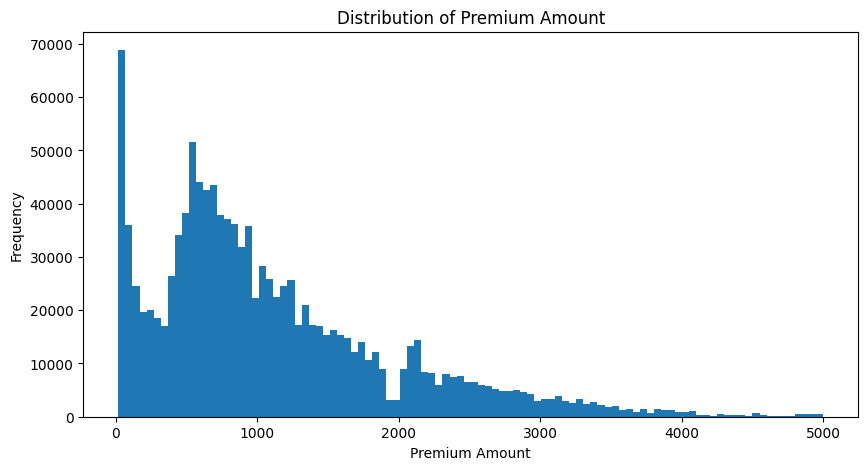

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.hist(train["Premium Amount"], bins=100)
plt.xlabel("Premium Amount")
plt.ylabel("Frequency")
plt.title("Distribution of Premium Amount")
plt.show()

In [12]:
train["Premium Amount"].skew()

np.float64(1.2409154932891036)

In [13]:
train["Premium Amount"].quantile([0.90, 0.95, 0.99, 0.999])

0.900    2363.0
0.950    2869.0
0.990    3841.0
0.999    4871.0
Name: Premium Amount, dtype: float64

In [14]:
train.groupby(train["Occupation"].isna())["Premium Amount"].agg(
    ["count", "mean", "median"]
)

,count,mean,median
Occupation,,,
False,841925,1106.467773,876.0
True,358075,1093.320969,861.0


In [15]:
train.groupby(train["Previous Claims"].isna())["Premium Amount"].agg(
    ["count", "mean", "median"]
)

,count,mean,median
Previous Claims,,,
False,835971,1113.692608,882.0
True,364029,1076.944592,845.0


In [16]:
train.groupby(train["Credit Score"].isna())["Premium Amount"].agg(
    ["count", "mean", "median"]
)

,count,mean,median
Credit Score,,,
False,1062118,1104.742516,874.0
True,137882,1085.615773,845.0


In [17]:
train.groupby(train["Number of Dependents"].isna())["Premium Amount"].agg(
    ["count", "mean", "median"]
)

,count,mean,median
Number of Dependents,,,
False,1090328,1100.141137,871.0
True,109672,1126.441571,892.0


In [18]:
train.groupby(train["Customer Feedback"].isna())["Premium Amount"].agg(
    ["count", "mean", "median"]
)

,count,mean,median
Customer Feedback,,,
False,1122176,1096.506106,863.0
True,77824,1189.619526,956.0


In [19]:
train.groupby(train["Health Score"].isna())["Premium Amount"].agg(
    ["count", "mean", "median"]
)

,count,mean,median
Health Score,,,
False,1125924,1098.893513,867.0
True,74076,1158.043172,930.0


In [20]:
train.groupby(train["Annual Income"].isna())["Premium Amount"].agg(
    ["count", "mean", "median"]
)

,count,mean,median
Annual Income,,,
False,1155051,1109.251625,882.0
True,44949,930.200605,556.0


In [21]:
train.groupby(train["Vehicle Age"].isna())["Premium Amount"].agg(
    ["count", "mean", "median"]
)

,count,mean,median
Vehicle Age,,,
False,1199994,1102.544345,872.0
True,6,1197.833333,935.5


In [22]:
train.groupby(train["Insurance Duration"].isna())["Premium Amount"].agg(
    ["count", "mean", "median"]
)

,count,mean,median
Insurance Duration,,,
False,1199999,1102.54487,872.0
True,1,1044.00000,1044.0


In [23]:
train["Age"].describe()

count    1.181295e+06
mean     4.114556e+01
std      1.353995e+01
min      1.800000e+01
25%      3.000000e+01
50%      4.100000e+01
75%      5.300000e+01
max      6.400000e+01
Name: Age, dtype: float64

In [24]:
train["Annual Income"].describe()

count    1.155051e+06
mean     3.274522e+04
std      3.217951e+04
min      1.000000e+00
25%      8.001000e+03
50%      2.391100e+04
75%      4.463400e+04
max      1.499970e+05
Name: Annual Income, dtype: float64

In [25]:
train["Number of Dependents"].describe()

count    1.090328e+06
mean     2.009934e+00
std      1.417338e+00
min      0.000000e+00
25%      1.000000e+00
50%      2.000000e+00
75%      3.000000e+00
max      4.000000e+00
Name: Number of Dependents, dtype: float64

In [26]:
train["Health Score"].describe()

count    1.125924e+06
mean     2.561391e+01
std      1.220346e+01
min      2.012237e+00
25%      1.591896e+01
50%      2.457865e+01
75%      3.452721e+01
max      5.897591e+01
Name: Health Score, dtype: float64

In [27]:
train["Previous Claims"].describe()

count    835971.000000
mean          1.002689
std           0.982840
min           0.000000
25%           0.000000
50%           1.000000
75%           2.000000
max           9.000000
Name: Previous Claims, dtype: float64

In [28]:
train["Vehicle Age"].describe()

count    1.199994e+06
mean     9.569889e+00
std      5.776189e+00
min      0.000000e+00
25%      5.000000e+00
50%      1.000000e+01
75%      1.500000e+01
max      1.900000e+01
Name: Vehicle Age, dtype: float64

In [29]:
train["Credit Score"].describe()

count    1.062118e+06
mean     5.929244e+02
std      1.499819e+02
min      3.000000e+02
25%      4.680000e+02
50%      5.950000e+02
75%      7.210000e+02
max      8.490000e+02
Name: Credit Score, dtype: float64

In [30]:
train["Insurance Duration"].describe()

count    1.199999e+06
mean     5.018219e+00
std      2.594331e+00
min      1.000000e+00
25%      3.000000e+00
50%      5.000000e+00
75%      7.000000e+00
max      9.000000e+00
Name: Insurance Duration, dtype: float64

In [31]:
train["Gender"].value_counts(dropna=False)

Gender
Male      602571
Female    597429
Name: count, dtype: int64

In [32]:
train["Marital Status"].value_counts(dropna=False)

Marital Status
Single      395391
Married     394316
Divorced    391764
NaN          18529
Name: count, dtype: int64

In [33]:
train["Education Level"].value_counts(dropna=False)

Education Level
Master's       303818
PhD            303507
Bachelor's     303234
High School    289441
Name: count, dtype: int64

In [34]:
train["Occupation"].value_counts(dropna=False)

Occupation
NaN              358075
Employed         282750
Self-Employed    282645
Unemployed       276530
Name: count, dtype: int64

In [35]:
train["Location"].value_counts(dropna=False)

Location
Suburban    401542
Rural       400947
Urban       397511
Name: count, dtype: int64

In [36]:
train["Policy Type"].value_counts(dropna=False)

Policy Type
Premium          401846
Comprehensive    399600
Basic            398554
Name: count, dtype: int64

In [37]:
train["Previous Claims"].value_counts(dropna=False).sort_index()

Previous Claims
0.0    305433
1.0    300811
2.0    167661
3.0     49011
4.0     10668
5.0      2018
6.0       302
7.0        58
8.0         8
9.0         1
NaN    364029
Name: count, dtype: int64

In [38]:
train["Customer Feedback"].value_counts(dropna=False)

Customer Feedback
Average    377905
Poor       375518
Good       368753
NaN         77824
Name: count, dtype: int64

In [39]:
train["Smoking Status"].value_counts(dropna=False)

Smoking Status
Yes    601873
No     598127
Name: count, dtype: int64

In [40]:
train["Exercise Frequency"].value_counts(dropna=False)

Exercise Frequency
Weekly     306179
Monthly    299830
Rarely     299420
Daily      294571
Name: count, dtype: int64

In [41]:
train["Property Type"].value_counts(dropna=False)

Property Type
House        400349
Apartment    399978
Condo        399673
Name: count, dtype: int64

In [42]:
train["Policy Start Date"].describe()

count                        1200000
unique                        167381
top       2020-02-08 15:21:39.134960
freq                             142
Name: Policy Start Date, dtype: object

In [43]:
train["Policy Start Date"] = pd.to_datetime(train["Policy Start Date"])

print("Minimum date:", train["Policy Start Date"].min())
print("Maximum date:", train["Policy Start Date"].max())

Minimum date: 2019-08-17 15:21:39.080371
Maximum date: 2024-08-15 15:21:39.287115


In [44]:
train["Policy Start Date"].dt.year.value_counts().sort_index()

Policy Start Date
2019     84289
2020    242087
2021    244918
2022    245671
2023    239067
2024    143968
Name: count, dtype: int64

In [45]:
train["Policy Start Date"].dt.hour.value_counts().sort_index()

Policy Start Date
15    1200000
Name: count, dtype: int64

In [46]:
train["Policy Start Date"].dt.month.value_counts().sort_index()

Policy Start Date
1      98535
2      95924
3     102909
4     100906
5     105176
6      98500
7     100772
8     101077
9      99377
10     99408
11     99894
12     97522
Name: count, dtype: int64

In [47]:
train["Policy Year"] = train["Policy Start Date"].dt.year
train["Policy Month"] = train["Policy Start Date"].dt.month
train["Policy Day"] = train["Policy Start Date"].dt.day

In [48]:
train[["Policy Start Date", "Policy Year", "Policy Month", "Policy Day"]].head()

,Policy Start Date,Policy Year,Policy Month,Policy Day
0,2023-12-23 15:21:39.134960,2023,12,23
1,2023-06-12 15:21:39.111551,2023,6,12
2,2023-09-30 15:21:39.221386,2023,9,30
3,2024-06-12 15:21:39.226954,2024,6,12
4,2021-12-01 15:21:39.252145,2021,12,1


In [49]:
reference_date = train["Policy Start Date"].max()

train["Policy Age Days"] = (
    reference_date - train["Policy Start Date"]
).dt.days

train[["Policy Start Date", "Policy Age Days"]].head()

,Policy Start Date,Policy Age Days
0,2023-12-23 15:21:39.134960,236
1,2023-06-12 15:21:39.111551,430
2,2023-09-30 15:21:39.221386,320
3,2024-06-12 15:21:39.226954,64
4,2021-12-01 15:21:39.252145,988


In [50]:
print("Train columns:", train.shape[1])
print("Test columns:", test.shape[1])

Train columns: 25
Test columns: 20


In [51]:
test["Policy Start Date"] = pd.to_datetime(test["Policy Start Date"])

test["Policy Year"] = test["Policy Start Date"].dt.year
test["Policy Month"] = test["Policy Start Date"].dt.month
test["Policy Day"] = test["Policy Start Date"].dt.day

test["Policy Age Days"] = (
    train["Policy Start Date"].max() - test["Policy Start Date"]
).dt.days

test[[
    "Policy Start Date",
    "Policy Year",
    "Policy Month",
    "Policy Day",
    "Policy Age Days"
]].head()

,Policy Start Date,Policy Year,Policy Month,Policy Day,Policy Age Days
0,2023-06-04 15:21:39.245086,2023,6,4,438
1,2024-04-22 15:21:39.224915,2024,4,22,115
2,2023-04-05 15:21:39.134960,2023,4,5,498
3,2023-10-25 15:21:39.134960,2023,10,25,295
4,2021-11-26 15:21:39.259788,2021,11,26,993


In [52]:
test_missing = pd.DataFrame({
    "Missing Count": test.isnull().sum(),
    "Missing Percentage": test.isnull().mean() * 100
})

test_missing = test_missing[test_missing["Missing Count"] > 0]
test_missing = test_missing.sort_values("Missing Count", ascending=False)

display(test_missing)

,Missing Count,Missing Percentage
Previous Claims,242802,30.350250
Occupation,239125,29.890625
Credit Score,91451,11.431375
Number of Dependents,73130,9.141250
Customer Feedback,52276,6.534500
Health Score,49449,6.181125
Annual Income,29860,3.732500
Age,12489,1.561125
Marital Status,12336,1.542000
Vehicle Age,3,0.000375


In [53]:
train.columns.tolist()

['id',
 'Age',
 'Gender',
 'Annual Income',
 'Marital Status',
 'Number of Dependents',
 'Education Level',
 'Occupation',
 'Health Score',
 'Location',
 'Policy Type',
 'Previous Claims',
 'Vehicle Age',
 'Credit Score',
 'Insurance Duration',
 'Policy Start Date',
 'Customer Feedback',
 'Smoking Status',
 'Exercise Frequency',
 'Property Type',
 'Premium Amount',
 'Policy Year',
 'Policy Month',
 'Policy Day',
 'Policy Age Days']

In [54]:
print("Train unique IDs:", train["id"].nunique())
print("Train rows:", len(train))

print("Test unique IDs:", test["id"].nunique())
print("Test rows:", len(test))

Train unique IDs: 1200000
Train rows: 1200000
Test unique IDs: 800000
Test rows: 800000


In [55]:
train["Policy Start Date"].head()

0   2023-12-23 15:21:39.134960
1   2023-06-12 15:21:39.111551
2   2023-09-30 15:21:39.221386
3   2024-06-12 15:21:39.226954
4   2021-12-01 15:21:39.252145
Name: Policy Start Date, dtype: datetime64[ns]

In [56]:
print(train[[
    "Policy Year",
    "Policy Month",
    "Policy Day",
    "Policy Age Days"
]].describe())

print("\nTest:")
print(test[[
    "Policy Year",
    "Policy Month",
    "Policy Day",
    "Policy Age Days"
]].describe())

        Policy Year  Policy Month    Policy Day  Policy Age Days
count  1.200000e+06  1.200000e+06  1.200000e+06     1.200000e+06
mean   2.021621e+03  6.492671e+00  1.570618e+01     9.144134e+02
std    1.476008e+00  3.432689e+00  8.811727e+00     5.214397e+02
min    2.019000e+03  1.000000e+00  1.000000e+00     0.000000e+00
25%    2.020000e+03  4.000000e+00  8.000000e+00     4.670000e+02
50%    2.022000e+03  6.000000e+00  1.600000e+01     9.130000e+02
75%    2.023000e+03  9.000000e+00  2.300000e+01     1.364000e+03
max    2.024000e+03  1.200000e+01  3.100000e+01     1.825000e+03

Test:
         Policy Year   Policy Month     Policy Day  Policy Age Days
count  800000.000000  800000.000000  800000.000000    800000.000000
mean     2021.621140       6.490782      15.716979       914.362084
std         1.476611       3.431483       8.804194       521.645814
min      2019.000000       1.000000       1.000000         0.000000
25%      2020.000000       4.000000       8.000000       466.000000


In [57]:
target = "Premium Amount"

categorical_features = train.select_dtypes(
    include=["object"]
).columns.tolist()

numerical_features = train.select_dtypes(
    include=["number"]
).columns.tolist()

print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)

Categorical features:
['Gender', 'Marital Status', 'Education Level', 'Occupation', 'Location', 'Policy Type', 'Customer Feedback', 'Smoking Status', 'Exercise Frequency', 'Property Type']

Numerical features:
['id', 'Age', 'Annual Income', 'Number of Dependents', 'Health Score', 'Previous Claims', 'Vehicle Age', 'Credit Score', 'Insurance Duration', 'Premium Amount', 'Policy Year', 'Policy Month', 'Policy Day', 'Policy Age Days']


In [58]:
features = [
    "Age",
    "Gender",
    "Annual Income",
    "Marital Status",
    "Number of Dependents",
    "Education Level",
    "Occupation",
    "Health Score",
    "Location",
    "Policy Type",
    "Previous Claims",
    "Vehicle Age",
    "Credit Score",
    "Insurance Duration",
    "Customer Feedback",
    "Smoking Status",
    "Exercise Frequency",
    "Property Type",
    "Policy Year",
    "Policy Month",
    "Policy Day",
    "Policy Age Days"
]

X = train[features].copy()
y = train["Premium Amount"].copy()

X_test = test[features].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)
print("X_test shape:", X_test.shape)

X shape: (1200000, 22)
y shape: (1200000,)
X_test shape: (800000, 22)


In [59]:
from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_valid:", X_valid.shape)
print("y_train:", y_train.shape)
print("y_valid:", y_valid.shape)

X_train: (960000, 22)
X_valid: (240000, 22)
y_train: (960000,)
y_valid: (240000,)


In [60]:
print("Missing values in X_train:")
display(X_train.isnull().sum()[X_train.isnull().sum() > 0])

print("\nMissing values in X_valid:")
display(X_valid.isnull().sum()[X_valid.isnull().sum() > 0])

Missing values in X_train:


Age                      15048
Annual Income            35914
Marital Status           14863
Number of Dependents     87864
Occupation              286621
Health Score             59329
Previous Claims         291155
Vehicle Age                  4
Credit Score            110274
Insurance Duration           1
Customer Feedback        62295
dtype: int64


Missing values in X_valid:


Age                      3657
Annual Income            9035
Marital Status           3666
Number of Dependents    21808
Occupation              71454
Health Score            14747
Previous Claims         72874
Vehicle Age                 2
Credit Score            27608
Customer Feedback       15529
dtype: int64

In [61]:
categorical_features = [
    "Gender",
    "Marital Status",
    "Education Level",
    "Occupation",
    "Location",
    "Policy Type",
    "Customer Feedback",
    "Smoking Status",
    "Exercise Frequency",
    "Property Type"
]

numerical_features = [
    "Age",
    "Annual Income",
    "Number of Dependents",
    "Health Score",
    "Previous Claims",
    "Vehicle Age",
    "Credit Score",
    "Insurance Duration",
    "Policy Year",
    "Policy Month",
    "Policy Day",
    "Policy Age Days"
]

print("Categorical features:", len(categorical_features))
print("Numerical features:", len(numerical_features))

Categorical features: 10
Numerical features: 12


In [62]:

train_medians = X_train[numerical_features].median()

display(train_medians)

Age                        41.000000
Annual Income           23935.500000
Number of Dependents        2.000000
Health Score               24.587778
Previous Claims             1.000000
Vehicle Age                10.000000
Credit Score              595.000000
Insurance Duration          5.000000
Policy Year              2022.000000
Policy Month                6.000000
Policy Day                 16.000000
Policy Age Days           913.000000
dtype: float64

In [63]:

X_train_processed = X_train.copy()
X_valid_processed = X_valid.copy()
X_test_processed = X_test.copy()


for col in numerical_features:
    if X_train_processed[col].isnull().any():
        X_train_processed[col + "_Missing"] = X_train_processed[col].isnull().astype("int8")
        X_valid_processed[col + "_Missing"] = X_valid_processed[col].isnull().astype("int8")
        X_test_processed[col + "_Missing"] = X_test_processed[col].isnull().astype("int8")


for col in numerical_features:
    median_value = train_medians[col]
    
    X_train_processed[col] = X_train_processed[col].fillna(median_value)
    X_valid_processed[col] = X_valid_processed[col].fillna(median_value)
    X_test_processed[col] = X_test_processed[col].fillna(median_value)


for col in categorical_features:
    X_train_processed[col] = X_train_processed[col].fillna("Missing")
    X_valid_processed[col] = X_valid_processed[col].fillna("Missing")
    X_test_processed[col] = X_test_processed[col].fillna("Missing")

print("X_train_processed:", X_train_processed.shape)
print("X_valid_processed:", X_valid_processed.shape)
print("X_test_processed:", X_test_processed.shape)

X_train_processed: (960000, 30)
X_valid_processed: (240000, 30)
X_test_processed: (800000, 30)


In [64]:

for col in numerical_features:
    median_value = train_medians[col]

    X_train_processed[col] = X_train_processed[col].fillna(median_value)
    X_valid_processed[col] = X_valid_processed[col].fillna(median_value)
    X_test_processed[col] = X_test_processed[col].fillna(median_value)


for col in categorical_features:
    X_train_processed[col] = X_train_processed[col].fillna("Missing")
    X_valid_processed[col] = X_valid_processed[col].fillna("Missing")
    X_test_processed[col] = X_test_processed[col].fillna("Missing")

print("Remaining missing values in X_train:",
      X_train_processed.isnull().sum().sum())

print("Remaining missing values in X_valid:",
      X_valid_processed.isnull().sum().sum())

print("Remaining missing values in X_test:",
      X_test_processed.isnull().sum().sum())

Remaining missing values in X_train: 0
Remaining missing values in X_valid: 0
Remaining missing values in X_test: 0


In [65]:
from sklearn.preprocessing import OrdinalEncoder

encoder = OrdinalEncoder(
    handle_unknown="use_encoded_value",
    unknown_value=-1
)

X_train_processed[categorical_features] = encoder.fit_transform(
    X_train_processed[categorical_features]
)

X_valid_processed[categorical_features] = encoder.transform(
    X_valid_processed[categorical_features]
)

X_test_processed[categorical_features] = encoder.transform(
    X_test_processed[categorical_features]
)

print("X_train_processed:", X_train_processed.shape)
print("X_valid_processed:", X_valid_processed.shape)
print("X_test_processed:", X_test_processed.shape)

X_train_processed: (960000, 30)
X_valid_processed: (240000, 30)
X_test_processed: (800000, 30)


In [66]:
print("Data types in X_train_processed:")
display(X_train_processed.dtypes)

print("\nNon-numeric columns:")
print(
    X_train_processed.select_dtypes(exclude=["number"]).columns.tolist()
)

Data types in X_train_processed:


Age                             float64
Gender                          float64
Annual Income                   float64
Marital Status                  float64
Number of Dependents            float64
Education Level                 float64
Occupation                      float64
Health Score                    float64
Location                        float64
Policy Type                     float64
Previous Claims                 float64
Vehicle Age                     float64
Credit Score                    float64
Insurance Duration              float64
Customer Feedback               float64
Smoking Status                  float64
Exercise Frequency              float64
Property Type                   float64
Policy Year                       int32
Policy Month                      int32
Policy Day                        int32
Policy Age Days                   int64
Age_Missing                        int8
Annual Income_Missing              int8
Number of Dependents_Missing       int8



Non-numeric columns:
[]


In [67]:
import numpy as np
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_squared_log_error

y_train_log = np.log1p(y_train)

baseline_model = HistGradientBoostingRegressor(
    max_iter=200,
    learning_rate=0.05,
    max_leaf_nodes=31,
    random_state=42
)

baseline_model.fit(X_train_processed, y_train_log)


y_valid_pred_log = baseline_model.predict(X_valid_processed)


y_valid_pred = np.expm1(y_valid_pred_log)


baseline_rmsle = np.sqrt(
    mean_squared_log_error(y_valid, y_valid_pred)
)

print("Baseline RMSLE:", baseline_rmsle)

Baseline RMSLE: 1.0468642733334321


In [68]:
print("Actual target:")
print(y_valid.describe())

print("\nPredicted target:")
print(pd.Series(y_valid_pred).describe())

print("\nNegative predictions:", (y_valid_pred < 0).sum())
print("Zero predictions:", (y_valid_pred == 0).sum())

Actual target:
count    240000.000000
mean       1102.701992
std         864.458617
min          20.000000
25%         514.000000
50%         872.000000
75%        1512.000000
max        4997.000000
Name: Premium Amount, dtype: float64

Predicted target:
count    240000.000000
mean        756.320833
std         148.762253
min         159.955222
25%         762.435689
50%         787.759834
75%         811.668108
max        1428.788228
dtype: float64

Negative predictions: 0
Zero predictions: 0


In [69]:
X_train_cb = X_train.copy()
X_valid_cb = X_valid.copy()
X_test_cb = X_test.copy()

for col in numerical_features:
    median_value = train_medians[col]
    
    X_train_cb[col] = X_train_cb[col].fillna(median_value)
    X_valid_cb[col] = X_valid_cb[col].fillna(median_value)
    X_test_cb[col] = X_test_cb[col].fillna(median_value)

for col in categorical_features:
    X_train_cb[col] = X_train_cb[col].fillna("Missing").astype(str)
    X_valid_cb[col] = X_valid_cb[col].fillna("Missing").astype(str)
    X_test_cb[col] = X_test_cb[col].fillna("Missing").astype(str)

print("Train:", X_train_cb.shape)
print("Validation:", X_valid_cb.shape)
print("Test:", X_test_cb.shape)

Train: (960000, 22)
Validation: (240000, 22)
Test: (800000, 22)


In [70]:
import importlib.util

print("CatBoost available:",
      importlib.util.find_spec("catboost") is not None)

CatBoost available: True


In [71]:
X_train_cb = X_train.copy()
X_valid_cb = X_valid.copy()
X_test_cb = X_test.copy()

for col in numerical_features:
    median_value = train_medians[col]
    
    X_train_cb[col] = X_train_cb[col].fillna(median_value)
    X_valid_cb[col] = X_valid_cb[col].fillna(median_value)
    X_test_cb[col] = X_test_cb[col].fillna(median_value)

for col in categorical_features:
    X_train_cb[col] = X_train_cb[col].fillna("Missing").astype(str)
    X_valid_cb[col] = X_valid_cb[col].fillna("Missing").astype(str)
    X_test_cb[col] = X_test_cb[col].fillna("Missing").astype(str)

print("Train:", X_train_cb.shape)
print("Validation:", X_valid_cb.shape)
print("Test:", X_test_cb.shape)

Train: (960000, 22)
Validation: (240000, 22)
Test: (800000, 22)


In [72]:
from catboost import CatBoostRegressor

y_train_log = np.log1p(y_train)
y_valid_log = np.log1p(y_valid)

catboost_model = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=8,
    loss_function="RMSE",
    eval_metric="RMSE",
    random_seed=42,
    verbose=100
)

print("CatBoost model is ready.")

CatBoost model is ready.


In [73]:
from catboost import CatBoostRegressor

catboost_model = CatBoostRegressor(
    iterations=200,
    learning_rate=0.1,
    depth=6,
    loss_function="RMSE",
    random_seed=42,
    verbose=50,
    task_type="CPU"
)

catboost_model.fit(
    X_train_cb,
    y_train_log,
    cat_features=categorical_features,
    eval_set=(X_valid_cb, y_valid_log),
    early_stopping_rounds=30
)

0:	learn: 1.0903438	test: 1.0911457	best: 1.0911457 (0)	total: 1.16s	remaining: 3m 51s
50:	learn: 1.0524569	test: 1.0535581	best: 1.0535581 (50)	total: 41.7s	remaining: 2m 1s
100:	learn: 1.0497033	test: 1.0510448	best: 1.0510426 (99)	total: 1m 21s	remaining: 1m 19s
150:	learn: 1.0484873	test: 1.0500492	best: 1.0500492 (150)	total: 2m	remaining: 39s
199:	learn: 1.0477910	test: 1.0495092	best: 1.0495092 (199)	total: 2m 36s	remaining: 0us

bestTest = 1.049509159
bestIteration = 199



CatBoostRegressor(depth=6, iterations=200, learning_rate=0.1, loss_function='RMSE', random_seed=42, task_type='CPU', verbose=50)

In [74]:
y_valid_pred_log_cb = catboost_model.predict(X_valid_cb)
y_valid_pred_cb = np.expm1(y_valid_pred_log_cb)

catboost_rmsle = np.sqrt(
    mean_squared_log_error(y_valid, y_valid_pred_cb)
)

print("CatBoost RMSLE:", catboost_rmsle)

CatBoost RMSLE: 1.0495091593458041


In [75]:
feature_importance = pd.Series(
    catboost_model.feature_importances_,
    index=X_train_cb.columns
).sort_values(ascending=False)

display(feature_importance.head(15))

Annual Income           45.713162
Credit Score            23.190358
Health Score            13.181397
Previous Claims          9.265576
Customer Feedback        4.349727
Policy Year              1.933807
Marital Status           1.065108
Policy Age Days          0.946165
Occupation               0.066079
Insurance Duration       0.061935
Age                      0.058606
Number of Dependents     0.053058
Vehicle Age              0.037070
Policy Day               0.028088
Policy Month             0.025630
dtype: float64

In [76]:
print("Best iteration:", catboost_model.get_best_iteration())
print("Best validation RMSE:", catboost_model.get_best_score()["validation"]["RMSE"])

Best iteration: 199
Best validation RMSE: 1.0495091587168923


In [77]:
id="t4n8p6"
print("Baseline RMSLE:", baseline_rmsle)
print("CatBoost RMSLE:", catboost_rmsle)
print("Difference:", catboost_rmsle - baseline_rmsle)

Baseline RMSLE: 1.0468642733334321
CatBoost RMSLE: 1.0495091593458041
Difference: 0.0026448860123720053


In [78]:
import importlib.util

print("LightGBM available:", importlib.util.find_spec("lightgbm") is not None)

LightGBM available: True


In [79]:
from lightgbm import LGBMRegressor

categorical_encoded = [
    "Gender",
    "Marital Status",
    "Education Level",
    "Occupation",
    "Location",
    "Policy Type",
    "Customer Feedback",
    "Smoking Status",
    "Exercise Frequency",
    "Property Type"
]

for col in categorical_encoded:
    X_train_processed[col] = X_train_processed[col].astype("category")
    X_valid_processed[col] = X_valid_processed[col].astype("category")
    X_test_processed[col] = X_test_processed[col].astype("category")

lgbm_model = LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
    n_jobs=-1
)

lgbm_model.fit(
    X_train_processed,
    y_train_log,
    categorical_feature=categorical_encoded
)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.071229 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1215
[LightGBM] [Info] Number of data points in the train set: 960000, number of used features: 28
[LightGBM] [Info] Start training from score 6.593848


LGBMRegressor(learning_rate=0.05, n_estimators=300, n_jobs=-1, random_state=42)

In [80]:
y_valid_pred_log_lgbm = lgbm_model.predict(X_valid_processed)
y_valid_pred_lgbm = np.expm1(y_valid_pred_log_lgbm)

lgbm_rmsle = np.sqrt(
    mean_squared_log_error(y_valid, y_valid_pred_lgbm)
)

print("Baseline RMSLE:", baseline_rmsle)
print("CatBoost RMSLE:", catboost_rmsle)
print("LightGBM RMSLE:", lgbm_rmsle)

Baseline RMSLE: 1.0468642733334321
CatBoost RMSLE: 1.0495091593458041
LightGBM RMSLE: 1.046493995000613


In [81]:
print("Number of boosting rounds:", lgbm_model.n_estimators_)
print("Best iteration:", lgbm_model.best_iteration_)

Number of boosting rounds: 300
Best iteration: 0


In [82]:
X_full = train[features].copy()
X_test_final = test[features].copy()

for col in numerical_features:
    median_value = X_full[col].median()
    X_full[col] = X_full[col].fillna(median_value)
    X_test_final[col] = X_test_final[col].fillna(median_value)

for col in categorical_features:
    X_full[col] = X_full[col].fillna("Missing").astype("category")
    X_test_final[col] = X_test_final[col].fillna("Missing").astype("category")

y_full_log = np.log1p(train["Premium Amount"])

print("Full train:", X_full.shape)
print("Test:", X_test_final.shape)

Full train: (1200000, 22)
Test: (800000, 22)


In [83]:
final_model = LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
    n_jobs=-1
)

final_model.fit(
    X_full,
    y_full_log,
    categorical_feature=categorical_features
)

print("Final model training completed.")

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.048093 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1204
[LightGBM] [Info] Number of data points in the train set: 1200000, number of used features: 22
[LightGBM] [Info] Start training from score 6.593889
Final model training completed.


In [84]:
test_pred_log = final_model.predict(X_test_final)
test_pred = np.expm1(test_pred_log)

test_pred = np.maximum(test_pred, 0)

print("Predictions:", len(test_pred))
print("Min:", test_pred.min())
print("Max:", test_pred.max())
print("Mean:", test_pred.mean())

Predictions: 800000
Min: 142.28140694283326
Max: 1302.3703652402319
Mean: 756.6949713424043


In [85]:
submission = pd.DataFrame({
    "id": test["id"],
    "Premium Amount": test_pred
})

submission.to_csv("submission.csv", index=False)

print("Submission shape:", submission.shape)
print(submission.head())

Submission shape: (800000, 2)
        id  Premium Amount
0  1200000      877.910810
1  1200001      804.325311
2  1200002      806.038498
3  1200003      801.095469
4  1200004      763.345071


In [86]:
sample_submission = pd.read_csv(
    "/kaggle/input/competitions/playground-series-s4e12/sample_submission.csv"
)

print("Sample columns:", sample_submission.columns.tolist())
print("Submission columns:", submission.columns.tolist())
print("Sample shape:", sample_submission.shape)
print("Submission shape:", submission.shape)
print("IDs match:", submission["id"].equals(sample_submission["id"]))

Sample columns: ['id', 'Premium Amount']
Submission columns: ['id', 'Premium Amount']
Sample shape: (800000, 2)
Submission shape: (800000, 2)
IDs match: True


In [87]:
print("Missing values:")
print(submission.isnull().sum())

print("\nNegative predictions:", (submission["Premium Amount"] < 0).sum())
print("Minimum prediction:", submission["Premium Amount"].min())
print("Maximum prediction:", submission["Premium Amount"].max())

Missing values:
id                0
Premium Amount    0
dtype: int64

Negative predictions: 0
Minimum prediction: 142.28140694283326
Maximum prediction: 1302.3703652402319


In [88]:
import os

submission_path = "submission.csv"

print("File exists:", os.path.exists(submission_path))
print("File size (MB):", round(os.path.getsize(submission_path) / (1024 ** 2), 2))

File exists: True
File size (MB): 19.78


In [89]:
print(submission.tail())

print("\nSubmission shape:", submission.shape)
print("Columns:", submission.columns.tolist())

             id  Premium Amount
799995  1999995      935.880757
799996  1999996      577.654399
799997  1999997      819.343678
799998  1999998      822.210545
799999  1999999      777.834327

Submission shape: (800000, 2)
Columns: ['id', 'Premium Amount']
